# `mosaic(source="DEA")` - Digital Earth Australia Sentinel-2

`source="DEA"` reads [Digital Earth Australia](https://www.dea.ga.gov.au/)'s Sentinel-2 analysis-ready data, published by Geoscience Australia. Everything else about `mosaic()` works the same: grid, bounds and AOI modes, every mosaic method, and both cloud masks.

Use it when you're working in Australia and want GA's NBART product. NBART is surface reflectance with BRDF and terrain correction, so it is more consistent across view angles and over hilly ground. MPC and AWS serve ESA's Sen2Cor L2A instead.

Differences from the default sources:

- **Australia only.**
- **NBART bands, no Sen2Cor outputs.** `visual`, `SCL`, `AOT`, `WVP` and `B09` aren't published. `cloud_mask="SCL"` reads DEA's fmask layer instead (same 20 m grid, classes translated to their SCL equivalents).
- **Final datasets only.** A final version usually appears 9-13 days after acquisition, so the most recent ~2 weeks are not available yet.
- **Same scale.** Bands come back as `reflectance * 10000`, like MPC and AWS.

## Install (Colab only)

Installs `s2mosaic` when running on Colab; a no-op locally.

In [1]:
try:
    import google.colab  # type: ignore # noqa: F401

    # --pre installs the v2 beta; drop this flag once 2.0.0 ships stable.
    %pip install --pre -q s2mosaic
except ImportError:
    pass

In [2]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from s2mosaic import mosaic


def stretch(array, lo=None, hi=None):
    """Percentile-stretch the first three bands to 0-1 for display."""
    rgb = np.moveaxis(array[:3], 0, -1).astype(float)
    valid = rgb[rgb > 0]
    if lo is None or hi is None:
        lo, hi = np.percentile(valid, [2, 98])
    return np.clip((rgb - lo) / max(hi - lo, 1), 0, 1), (lo, hi)


def plot_rgb(array, title=None, figsize=(8, 6)):
    rgb, _ = stretch(array)
    plt.figure(figsize=figsize)
    plt.imshow(rgb)
    if title:
        plt.title(title)
    plt.axis("off")
    plt.show()

## 1. A DEA mosaic

The same Perth AOI as [Example use - bounds.ipynb](Example%20use%20-%20bounds.ipynb), over two winter months, so there's cloud for the mask to remove. Bounds are in the local UTM zone and `snap_to_source_grid=True` keeps every pixel on the native 10 m grid.

`cloud_mask="SCL"` on DEA reads fmask: one 20 m COG read per scene and no model inference, so it's quick on a CPU.

In [3]:
# ~7.6km x 3.4km AOI near Perth, WA, in UTM zone 50S (EPSG:32750).
bounds = (389410, 6462290, 397010, 6465700)

request = dict(
    bounds=bounds,
    input_crs=32750,
    snap_to_source_grid=True,
    start_year=2023,
    start_month=6,
    duration_months=2,
    bands=["B04", "B03", "B02", "B08"],
    mosaic_method="median",
    cloud_mask="SCL",  # fmask on DEA
)

dea, profile = mosaic(**request, source="DEA", show_progress=True)

print(f"Shape: {dea.shape}  dtype: {dea.dtype}")
print(f"CRS:   {profile['crs']}")
print(f"Pixel: {profile['transform'].a}m")

Phase 1: streaming SCL cloud masks:   0%|          | 0/12 [00:00<?, ?scene/s]

Phase 2: aggregating tiles (percentile):   0%|          | 0/40 [00:00<?, ?read/s]

Shape: (4, 341, 760)  dtype: uint16
CRS:   EPSG:32750
Pixel: 10.0m


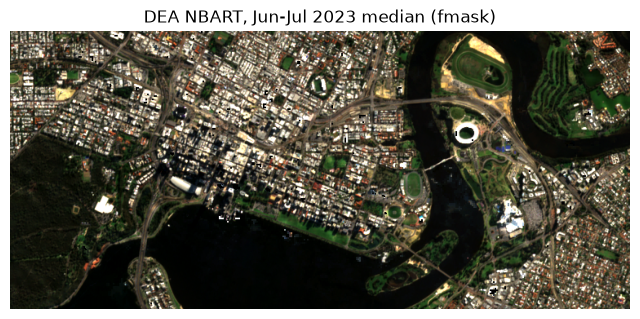

In [4]:
plot_rgb(dea, "DEA NBART, Jun-Jul 2023 median (fmask)")

## 2. DEA against AWS

The same request from Element 84's Sen2Cor L2A. Both sources return `reflectance * 10000`, so the numbers are directly comparable; the images below share one stretch.

They won't match, and by how much depends on the season. NBART's BRDF correction normalises every scene to a fixed sun angle, so when the real sun is low the correction brightens the image. In this winter window DEA's visible bands read roughly 25-45% above AWS, while NIR is within a few percent. For January 2023 over the same AOI, with a high summer sun, the visible bands were within 7% and NIR was about 8% lower. Don't mix DEA and L2A mosaics in one analysis without accounting for this.

Phase 1: streaming SCL cloud masks:   0%|          | 0/11 [00:00<?, ?scene/s]

Phase 2: aggregating tiles (percentile):   0%|          | 0/40 [00:00<?, ?read/s]

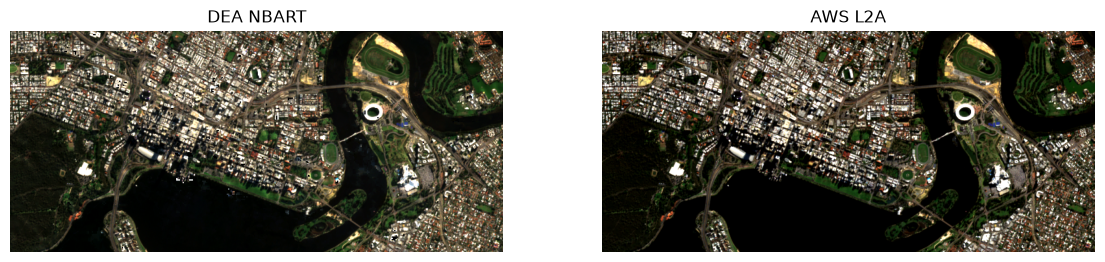

,DEA median,AWS median,DEA - AWS (%)
B04,718.0,580.0,23.8
B03,756.0,603.0,25.4
B02,539.0,378.0,42.6
B08,1770.0,1734.0,2.1


In [5]:
aws, _ = mosaic(**request, source="AWS", show_progress=True)

_, (lo, hi) = stretch(dea)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, arr, name in zip(axes, [dea, aws], ["DEA NBART", "AWS L2A"], strict=True):
    ax.imshow(stretch(arr, lo, hi)[0])
    ax.set_title(name)
    ax.axis("off")
plt.show()

both = (dea.min(axis=0) > 0) & (aws.min(axis=0) > 0)
summary = pd.DataFrame(
    {
        "DEA median": np.median(dea[:, both], axis=1),
        "AWS median": np.median(aws[:, both], axis=1),
    },
    index=request["bands"],
)
summary["DEA - AWS (%)"] = (
    100 * (summary["DEA median"] - summary["AWS median"]) / summary["AWS median"]
).round(1)
summary

## 3. fmask or OmniCloudMask

Both cloud masks work on DEA. `cloud_mask="OCM"` (the default) runs the OmniCloudMask model on the NBART red, green and NIR bands; it is more accurate than fmask but needs more compute.

`include_observation_count=True` appends a band counting the clear observations behind each pixel, which shows where each mask kept or rejected data.

Phase 1: streaming SCL cloud masks:   0%|          | 0/12 [00:00<?, ?scene/s]

Phase 2: aggregating tiles (percentile):   0%|          | 0/40 [00:00<?, ?read/s]

Phase 1: streaming bands for OCM cloud mask:   0%|          | 0/12 [00:00<?, ?scene/s]

Phase 2: aggregating tiles (percentile):   0%|          | 0/36 [00:00<?, ?read/s]

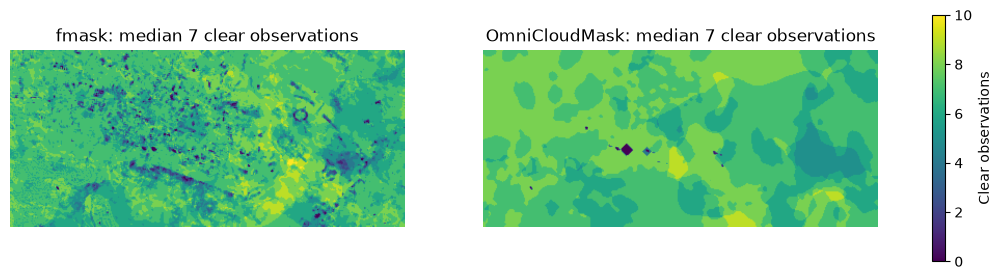

In [6]:
counts = {}
for mask in ["SCL", "OCM"]:
    arr, _ = mosaic(
        **{**request, "cloud_mask": mask},
        source="DEA",
        include_observation_count=True,
        show_progress=True,
    )
    counts[mask] = arr[-1]

vmax = max(c.max() for c in counts.values())
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (mask, count) in zip(axes, counts.items(), strict=True):
    im = ax.imshow(count, vmin=0, vmax=vmax, cmap="viridis")
    label = "fmask" if mask == "SCL" else "OmniCloudMask"
    ax.set_title(f"{label}: median {np.median(count):.0f} clear observations")
    ax.axis("off")
fig.colorbar(im, ax=axes, shrink=0.8, label="Clear observations")
plt.show()

## 4. A whole MGRS tile

`grid_id` works the same way; on DEA the tile filter is the dataset's `odc:region_code`.

**Pick the resolution with DEA's overviews in mind.** DEA's COGs only have overviews at 8x, 16x and 32x (80, 160 and 320 m for the 10 m bands). MPC and AWS also have 2x and 4x. At any resolution between native and 80 m, a DEA read has no overview to use and downloads the full-resolution band: a whole tile at 60 m takes minutes per scene, where 80 m takes about a second. Small bounds and AOIs are barely affected, because only the window is read. For a whole tile, use the native resolution or 80 m and coarser. Grid mode also needs a resolution that divides the 109,800 m tile evenly, or the pixels are stretched slightly to fit; 90 m satisfies both.

`additional_query` is written in the STAC Query extension's form as for every source. DEA's API only accepts CQL2 filters, so S2Mosaic translates it (`eq`, `neq`, `lt`, `lte`, `gt`, `gte`, `in`). DEA's `eo:cloud_cover` is fmask's cloud percentage.

Phase 1: streaming SCL cloud masks:   0%|          | 0/20 [00:00<?, ?scene/s]

Phase 2: aggregating tiles (percentile):   0%|          | 0/60 [00:00<?, ?read/s]

Shape: (3, 1220, 1220)  pixel: 90.0m


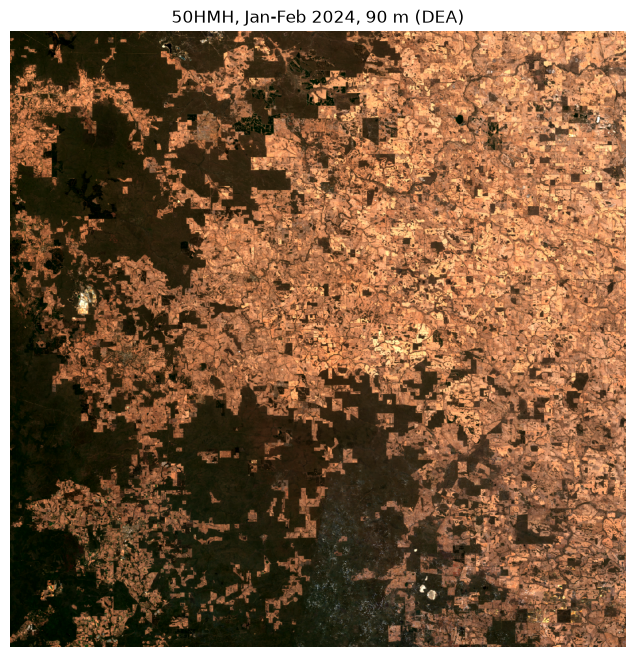

In [7]:
tile, tile_profile = mosaic(
    grid_id="50HMH",
    start_year=2024,
    start_month=1,
    duration_months=2,  # fmask misses small cumulus; more looks let the median drop it
    bands=["B04", "B03", "B02"],
    mosaic_method="median",
    resolution=90,  # >= 80 m uses DEA's 8x overview; divides 109,800 m evenly
    cloud_mask="SCL",
    additional_query={"eo:cloud_cover": {"lt": 50}},
    source="DEA",
    show_progress=True,
)
print(f"Shape: {tile.shape}  pixel: {tile_profile['transform'].a}m")
plot_rgb(tile, "50HMH, Jan-Feb 2024, 90 m (DEA)", figsize=(8, 8))

## 5. What DEA doesn't serve

Bands DEA doesn't publish are rejected before any data is fetched, with a message listing what is available.

In [8]:
for bands in (["visual"], ["B09"], ["SCL"]):
    try:
        mosaic(
            bounds=bounds, input_crs=32750, start_year=2023, bands=bands, source="DEA"
        )
    except ValueError as exc:
        print(f"{bands}: {exc}")

['visual']: Band visual is not available from source 'DEA'; it serves ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B11', 'B12', 'B8A']
['B09']: Band B09 is not available from source 'DEA'; it serves ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B11', 'B12', 'B8A']
['SCL']: Band SCL is not available from source 'DEA'; it serves ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B11', 'B12', 'B8A']


Only `final` datasets are searched. DEA also publishes provisional `nrt` and `interim` versions in the first weeks after acquisition, but these are excluded, so a window ending in the last ~2 weeks will contain fewer scenes than the same window on MPC or AWS, and one entirely inside it will find none.

## 6. Save to disk

As with any source, `output_dir` writes a GeoTIFF with an auto-generated name, which includes the source, plus a `.json` sidecar with the normalised request.

In [9]:
result = mosaic(**request, source="DEA", output_dir=Path("output"))
print(f"Saved to: {result.name}")

metadata = json.loads(result.with_suffix(".json").read_text())
{
    key: metadata["request"][key]
    for key in ["source", "bands", "mosaic_method", "cloud_mask"]
}

Saved to: bbox-115p8296_neg31p9707_115p9104_neg31p9393_2023-06-01_to_2023-08-01_B04-B03-B02-B08_percentile-p50_scene-valid_data_10m_SCL_DEA_e6ad78e931.tif


{'source': 'DEA',
 'bands': ['B04', 'B03', 'B02', 'B08'],
 'mosaic_method': 'percentile',
 'cloud_mask': 'SCL'}